# K-Nearest Neighbors (KNN)
### Author: Krzysztof Chmielewski

This notebook implements and visualizes K-Nearest Neighbors for regression (and classification variants) using simple synthetic datasets.

## Model Purpose and Applications

KNN is a non-parametric, instance-based algorithm used for classification and regression that makes predictions based on the labels/values of the k closest training examples in feature space.

### Key Use Cases:
- Recommendation systems (simple heuristics), anomaly detection, local approximations, baseline models for classification/regression.

### Core Concepts
- Distance metric (e.g., Euclidean):

$$d(x^{(1)},x^{(2)})=\sqrt{\sum_{i=1}^d (x_i^{(1)} - x_i^{(2)})^2}$$

- Classification: majority vote among k nearest neighbors.
- Regression: average (or weighted average) of k neighbors' values.
- Important practical points: choose `k`, scale features before computing distances, use efficient indexing for large datasets.

### Strengths & Limitations
- Strengths: very simple, no training phase (lazy learner), flexible with any distance metric.
- Limitations: prediction time is expensive, suffers from the curse of dimensionality, needs feature scaling and careful choice of `k`.

In [45]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [85]:
def create_synthetic_data(n: int = 1000, d: int = 5, noise: float = 0.1):
    X = np.random.randn(n, d)

    true_w = np.random.randint(0, 20, d)
    y = X @ true_w + noise * np.random.randn(n)

    return X, y, true_w

def visualize_neighbors(model, X, y, x_query, y_query, X_label=''):
    distances = model._distances(x_query.reshape(1, -1))[0]
    idx = np.argpartition(distances, model.k)[:model.k]

    plt.figure(figsize=(8,8))
    plt.scatter(X[:,0], X[:,1], alpha=0.5, label=X_label)

    plt.scatter(x_query[0], x_query[1], c='red', label='query')
    plt.text(x_query[0], x_query[1] + 0.1, f"{y_query:.2f}", ha='center', fontsize=8, color='red', weight='bold')

    nn_points = X[idx]
    plt.scatter(nn_points[:, 0], nn_points[:, 1],
                s=150, facecolors='none', edgecolors='black',
                linewidths=2, label='neighbors')
    
    for i in idx:
        plt.text(X[i,0], X[i,1] + 0.1, f"{y[i]:.2f}", ha='center', fontsize=8)
        plt.plot([x_query[0], X[i,0]], [x_query[1], X[i,1]], "k--", alpha=0.4)
    
    plt.legend()
    plt.title(f"{model.k} nearest neighbors in {model.X_train.shape[1]} dimensions")
    plt.show()

In [47]:
class KNNBase:
    def __init__(self, k: int = 3, metric: str = 'euclidean'):
        self.k = k
        if metric not in ('euclidean', 'manhattan'):
            raise ValueError('Unsupported distance metric')
        self.metric = metric
    
    def _distances(self, X):
        match self.metric:
            case 'euclidean': return np.sqrt(np.sum((X[:, None, :] - self.X_train[None, :, :])**2, axis=2))
            case 'manhattan': return np.sum(np.abs(X[:, None, :] - self.X_train[None, :, :], axis=2))

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
class KNNClassifier(KNNBase):
    def predict(self, X):
        distances = self._distances(X)
        idx_for_knn = np.argpartition(distances, self.k, axis=1)[:, :self.k]
        neighbor_labels = self.y_train[idx_for_knn]
        preds = np.array([np.bincount(row).argmax() for row in neighbor_labels])

        return preds

class KNNRegressor(KNNBase):
    def predict(self, X):
        distances = self._distances(X)
        idx_for_knn = np.argpartition(distances, self.k, axis=1)[:, :self.k]
        neighbor_vals = self.y_train[idx_for_knn]

        return neighbor_vals.mean(axis=1)
       

In [93]:
X, y, true_w = create_synthetic_data(n=50, d=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

knn = KNNRegressor(k=5)
knn.fit(X_train, y_train)

preds = knn.predict(X_test)
print(preds[:10])

[ -5.7817034  -25.01866653 -11.03632346  -0.99071313  22.5436125
 -17.14116451  10.6870831    4.76455708  -3.19580691 -20.83351434]


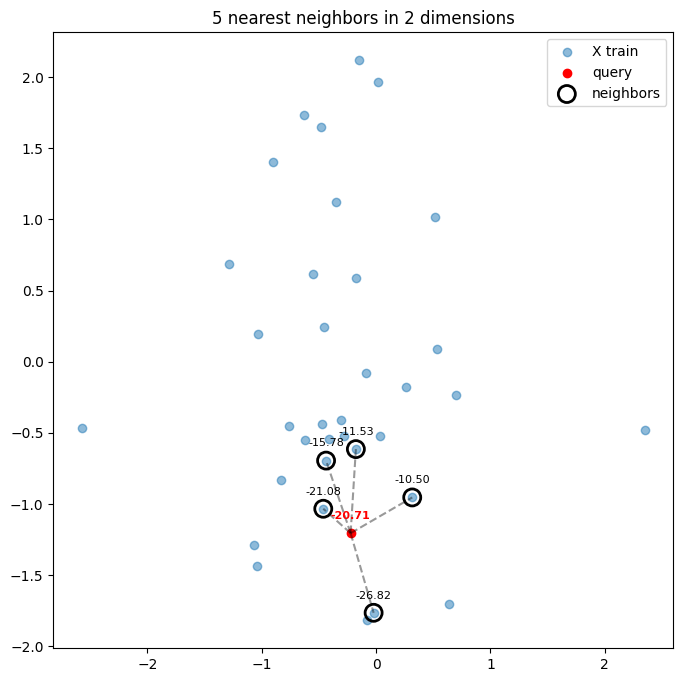

In [99]:
i = 5
x_query = X_test[i]
y_query_pred = y_test[i]
visualize_neighbors(knn, X_train, y_train, x_query, y_query_pred, "X train")